# GReinSS — Hands-on Tutorial
### Generative Reinforcement Learning of Structured States
*NCI Spring School on Algorithmic Cancer Biology*

Learn a distribution over **discrete latent states** $S$ from **indirect observations** $X$, given only the forward model $\Pr(X\mid S)$.

**What you supply is just two functions:**
1. a way to **generate** a state $S$ (grow it action by action), and
2. the likelihood $\Pr(X\mid S)$.

GReinSS trains a policy $\Pr(S\mid\theta)$ by policy gradients with the **dynamically rescaled reward**
$$r(\tau)=\sum_{i=1}^N \frac{\Pr(X_i\mid\tau)}{\Pr(X_i\mid\theta)},$$
which makes the gradient an **unbiased estimator** of $\frac{d}{d\theta}\log\Pr(X_{1:N}\mid\theta)$ (maximum likelihood).

**Notebook plan**
- **Setup**
- **Demo 1 — Set reconstruction** (trained *live*): recover binary sets from noisy measurements and beat naive thresholding.
- **Demo 2 — Scaling up**: the exact Demo 1 recipe *collapses* at $|\mathcal U|=1000$ (on-policy cannot sample the ~180-element sets) - then **off-policy sampling** fixes it.
- **Demo 3 — Graph inference** (pre-trained): a third latent structure — reconstruct directed graphs from random-walk endpoints and score $F_1$.
- **Intuition — the toy example**: why the denominator matters, shown numerically.


## Setup

Point Python at the GReinSS `code/` directory and import the library. We also patch `torch.load` (newer PyTorch defaults to `weights_only=True`, which cannot load these pickled models).

In [1]:
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
import contextlib, io

# --- locate the tutorial dir, the GReinSS code (git submodule at tutorial/code), and assets.
#     Robust to re-running this cell: after os.chdir(CODE) below, cwd becomes tutorial/code,
#     so we detect that and recover the true tutorial/ dir instead of nesting into code/assets. ---
_here = os.path.abspath(os.getcwd())
if os.path.isdir(os.path.join(_here, 'assets')):
    TUTORIAL = _here                                             # started in tutorial/
elif os.path.basename(_here) == 'code' and os.path.isdir(os.path.join(_here, '..', 'assets')):
    TUTORIAL = os.path.dirname(_here)                            # re-run: cwd is now tutorial/code
else:
    TUTORIAL = _here
ASSETS = os.path.join(TUTORIAL, 'assets')
CODE   = os.path.join(TUTORIAL, 'code')                          # git submodule -> elkebir-group/GReinSS
if not os.path.isdir(CODE):                                      # fallback to a sibling ../code checkout
    CODE = os.path.abspath(os.path.join(TUTORIAL, '..', 'code'))
sys.path.insert(0, CODE)
os.chdir(CODE)
_disp = os.path.dirname(TUTORIAL)                               # show paths repo-relative, not machine-absolute
print('tutorial dir:', os.path.relpath(TUTORIAL, _disp))
print('GReinSS code:', os.path.relpath(CODE, _disp))
print('assets:', os.path.relpath(ASSETS, _disp))

# --- PyTorch >= 2.6 loads with weights_only=True by default; these models need False.
#     Patch idempotently: re-running this cell must NOT re-wrap torch.load, or the wrappers
#     chain into infinite self-recursion (RecursionError on the next torch.load). ---
if not getattr(torch.load, '_greinss_patched', False):
    def _greinss_load(*a, _orig=torch.load, **k):   # capture the real torch.load in a default arg
        return _orig(*a, **{**k, 'weights_only': False})
    _greinss_load._greinss_patched = True
    torch.load = _greinss_load

@contextlib.contextmanager
def quiet():
    """Silence the GReinSS library's internal debug prints (progress counters, tensors) during inference."""
    with contextlib.redirect_stdout(io.StringIO()):
        yield

from sharedGen import (GraphGeneratorNet, gClass, train_model_off_policy,
                       simpleInference, generate_graph_batch_with_modified_policy)
np.random.seed(0)
torch.manual_seed(0)
print('numpy', np.__version__, '| torch', torch.__version__, '| ready')


tutorial dir: tutorial
GReinSS code: tutorial/code
assets: tutorial/assets
numpy 2.2.6 | torch 2.11.0 | ready


---
# Demo 1 — Set reconstruction *(trained live)*

**Problem.** Each latent state $S^*_i$ is a **subset** of a universe $\mathcal U$ of $|\mathcal U|=100$ elements.
We never see $S^*_i$; we observe a noisy real-valued vector
$$X_{i,j}\sim\mathcal N(1,\sigma^2)\ \text{if}\ j\in S^*_i,\qquad X_{i,j}\sim\mathcal N(0,\sigma^2)\ \text{otherwise},$$
with $\sigma=0.5$. This is the shape of many assays: noisy per-element readouts of which conditions
are "on" (active genes from expression, detected chemicals from mass-spec intensities, ...).

We use the **paper's own set-reconstruction data**. The ground-truth sets have **shared structure** —
each set is a union of a few reusable "modules" — so that a *shared* model $\Pr(S\mid\theta)$ can pool
information across observations. The naive baseline, **thresholding** each observation at 0.5, treats
every element independently.


observations X: (100, 100)    (ground-truth S* is hidden from the model)
avg set size: 23 of 100 elements


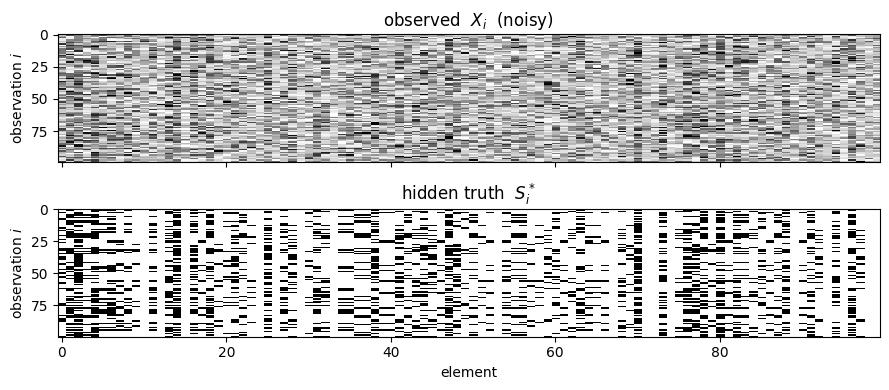

In [2]:
# ---- load the paper's set-reconstruction data: |U|=100 elements, sigma=0.5, N=100 observations ----
U, sigma = 100, 0.5
observations = np.load(os.path.join(ASSETS, 'set100_obs.npz'))['arr_0']    # noisy observations X  (N,|U|)
truth        = np.load(os.path.join(ASSETS, 'set100_truth.npz'))['arr_0']  # hidden ground-truth sets S*  (N,|U|)
N = observations.shape[0]
print('observations X:', observations.shape, '   (ground-truth S* is hidden from the model)')
print(f'avg set size: {truth.sum(1).mean():.0f} of {U} elements')

# peek: noisy observation (top) vs the hidden true set (bottom)
fig, ax = plt.subplots(2, 1, figsize=(9, 4), sharex=True, sharey=True)
ax[0].imshow(observations, aspect='auto', cmap='Greys', vmin=-1, vmax=2, interpolation='nearest')
ax[0].set_ylabel('observation $i$')
ax[0].set_title('observed  $X_i$  (noisy)')
ax[1].imshow(truth, aspect='auto', cmap='Greys', vmin=0, vmax=1, interpolation='nearest')
ax[1].set_ylabel('observation $i$')
ax[1].set_xlabel('element')
ax[1].set_title('hidden truth  $S^*_i$')
plt.tight_layout()
plt.show()

### The two ingredients you provide

**(1) The likelihood $\Pr(X\mid S)$.** For Gaussian noise this is just a squared-error term.
GReinSS wants a *vectorized* `multi_x_given_g(states, observations)` returning the matrix of
$\log\Pr(X_i\mid S_j)$ — states are binary vectors here, so $S$ *is* the mean of $X$.

**(2) The generator.** `GraphGeneratorNet` is the GReinSS policy that builds a state by adding
elements one at a time (then a stop action). You give it the state size, a final-probability
head size (`1` here — a single observation type, so no per-sample weighting), and the hidden width.

In [3]:
# Ingredient (1): vectorized log Pr(X | S):  states are 0/1 vectors; X ~ N(state, sigma^2)
def multi_x_given_g(states, obs):
    obs    = torch.tensor(obs).float().to(states.device)
    states = states.reshape(states.shape[0], 1, states.shape[1])   # (n_states, 1, U)
    obs    = obs.reshape(1, obs.shape[0], obs.shape[1])            # (1, n_obs,  U)
    return -0.5 * torch.sum((states - obs) ** 2, axis=2) / (sigma ** 2)

# Ingredient (2): the policy that generates sets, plus hyperparameters -> a single rule object
rule = gClass()
rule.graphSize          = U                               # size of the state (universe size)
rule.observations_batch = observations                    # the data X_{1:N}
rule.batchSize          = 1000                            # states sampled per step (large = better)
rule.learning_rate      = 1e-3
rule.model              = GraphGeneratorNet(U, 1, 64, endingBias=0)  # GReinSS generator, 64 hidden units
rule.multi_x_given_g    = multi_x_given_g

print('rule object ready — generator + Pr(X|S) supplied.')


rule object ready — generator + Pr(X|S) supplied.


### Train — live

We run a few hundred policy-gradient steps (~10 s). Watch the **median log-likelihood**
$\log\Pr(X_i\mid\theta)$ climb toward 0: the model is learning the distribution of sets that
best explains *all* the observations at once.

Epoch 1/800, Average Reward: -83.80342102050781, Median: -81.8031234741211
Epoch 11/800, Average Reward: -77.43354797363281, Median: -75.5048599243164
Epoch 21/800, Average Reward: -74.70170593261719, Median: -72.05117797851562
Epoch 31/800, Average Reward: -73.96110534667969, Median: -70.88101959228516
Epoch 41/800, Average Reward: -72.98918914794922, Median: -70.04423522949219
Epoch 51/800, Average Reward: -72.96212005615234, Median: -69.91921997070312
Epoch 61/800, Average Reward: -72.86437225341797, Median: -69.57192993164062
Epoch 71/800, Average Reward: -72.06765747070312, Median: -69.10681915283203
Epoch 81/800, Average Reward: -72.02326965332031, Median: -68.94322204589844
Epoch 91/800, Average Reward: -71.34565734863281, Median: -67.75212860107422
Epoch 101/800, Average Reward: -70.6703872680664, Median: -66.69029998779297
Epoch 111/800, Average Reward: -70.03921508789062, Median: -66.36922454833984
Epoch 121/800, Average Reward: -69.23002624511719, Median: -65.90711975097656


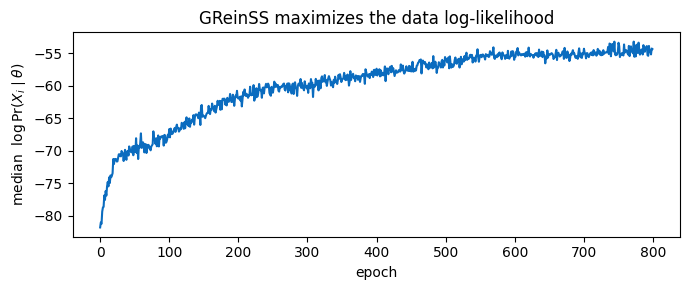

In [4]:
SET_MODEL = './_tutorial_set_model.pt'
t = time.time()
train_model_off_policy(rule, rule.learning_rate, rule.batchSize, offPolicy=False,
                       num_epochs=800, model_filename=SET_MODEL,
                       saveTrainingLoss='./_tutorial_set_loss.npz')
print(f'\ntrained in {time.time()-t:.1f} s')

loss = np.load('./_tutorial_set_loss.npz')['arr_0']
plt.figure(figsize=(7,3))
plt.plot(loss, color='#0b6cbf')
plt.xlabel('epoch')
plt.ylabel('median  $\\log\\Pr(X_i\\mid\\theta)$')
plt.title('GReinSS maximizes the data log-likelihood')
plt.tight_layout()
plt.show()


### Infer the sets, and compare to naive thresholding

`simpleInference` samples from the trained policy and, for each observation $X_i$, returns the
state $\hat S_i=\arg\max_S \Pr(X_i\mid S)\Pr(S\mid\theta)$. Because $\Pr(S\mid\theta)$ is **shared**,
GReinSS can override noisy elements that thresholding gets wrong.

In [5]:
with quiet():
    pred = np.array(simpleInference(rule, SET_MODEL)).astype(int)   # GReinSS predictions
thr  = (observations > 0.5).astype(int)                             # naive per-element thresholding

def f1(P, T):
    tp = ((P==1)&(T==1)).sum()
    fp = ((P==1)&(T==0)).sum()
    fn = ((P==0)&(T==1)).sum()
    prec = tp/(tp+fp+1e-9)
    rec = tp/(tp+fn+1e-9)
    return 2*prec*rec/(prec+rec+1e-9)

print(f"element F1     |  GReinSS {f1(pred,truth):.3f}   vs   thresholding {f1(thr,truth):.3f}")
print(f"exact-set acc  |  GReinSS {(pred==truth).all(1).mean():.2f}     vs   thresholding {(thr==truth).all(1).mean():.2f}")


element F1     |  GReinSS 0.845   vs   thresholding 0.706
exact-set acc  |  GReinSS 0.12     vs   thresholding 0.00


thresholding  false positives: 1265   false negatives:  359
GReinSS       false positives:  200   false negatives:  473


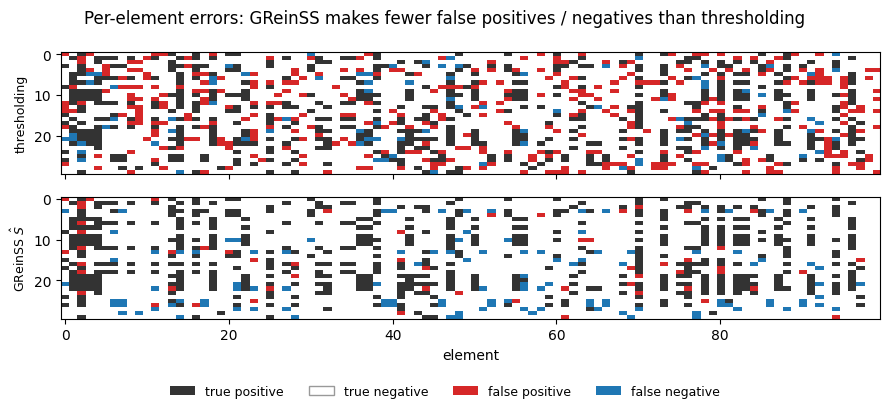

In [6]:
# where does GReinSS beat thresholding?  colour each element by error type vs. the hidden truth
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

def error_map(M, T):
    code = np.zeros_like(T, dtype=int)         # 0 = true negative  (correctly absent)
    code[(M==1)&(T==1)] = 1                     # true positive      (correctly present)
    code[(M==1)&(T==0)] = 2                     # false positive     (wrongly present)
    code[(M==0)&(T==1)] = 3                     # false negative     (wrongly absent)
    return code

cmap = ListedColormap(['#ffffff', '#333333', '#d62728', '#1f77b4'])  # TN, TP, FP, FN
norm = BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5], cmap.N)

for name, M in [('thresholding', thr), ('GReinSS', pred)]:
    fp = int(((M==1)&(truth==0)).sum())
    fn = int(((M==0)&(truth==1)).sum())
    print(f"{name:12s}  false positives: {fp:4d}   false negatives: {fn:4d}")

fig, ax = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
for a, M, t_ in zip(ax, [thr, pred], ['thresholding', 'GReinSS $\\hat S$']):
    a.imshow(error_map(M, truth)[:30], aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
    a.set_ylabel(t_, fontsize=9)
ax[-1].set_xlabel('element')
handles = [Patch(facecolor='#333333', label='true positive'),
           Patch(facecolor='#ffffff', edgecolor='#999999', label='true negative'),
           Patch(facecolor='#d62728', label='false positive'),
           Patch(facecolor='#1f77b4', label='false negative')]
fig.legend(handles=handles, ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           frameon=False, fontsize=9)
plt.suptitle('Per-element errors: GReinSS makes fewer false positives / negatives than thresholding')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

> **Takeaway.** Same four-line recipe as the README (`gClass` → set `multi_x_given_g` →
> `train_model_off_policy` → `simpleInference`). The shared model $\Pr(S\mid\theta)$ lets GReinSS
> beat independent thresholding — exactly the gain that scales to large universes in the paper.

---
# Demo 2 — Scaling up: does the same recipe still hold?

Demo 1 worked at $|\mathcal U|=100$. Now keep **everything the same** — same set-reconstruction
problem, same GReinSS recipe — but make the universe **10x larger**: $|\mathcal U|=1000$. The hidden
sets grow with it — **~180 of 1000** elements "on" (about the **same density** as Demo 1's ~23 of 100),
so each set is one specific ~180-element subset of a **vastly bigger** space. We load the paper's real
$|\mathcal U|=1000$ data and run the **exact on-policy recipe from Demo 1**.

The question: does simply scaling up still work?

In [7]:
# ---- the large set problem: |U|=1000. Load the paper's data (same shape as Demo 1, just bigger) ----
setoff_obs   = np.load(os.path.join(ASSETS, 'setoff_obs.npz'))['arr_0']    # (100,1000) noisy X
setoff_truth = np.load(os.path.join(ASSETS, 'setoff_truth.npz'))['arr_0']  # (100,1000) hidden sets S*
Ub, Nb, sig_b = setoff_obs.shape[1], setoff_obs.shape[0], 0.3
print(f'|U|={Ub},  N={Nb} observations,  avg set size {setoff_truth.sum(1).mean():.0f} elements')

# the SAME two ingredients as Demo 1, just vectorized for the larger size:
# memory-efficient log Pr(X|S) = -||s-o||^2 / 2*sigma^2  (naive form would build a huge (states,obs,U) tensor)
def multi_x_given_g_big(states, o):
    o = torch.as_tensor(o).float().to(states.device)
    s2 = states.sum(1, keepdim=True)
    o2 = (o*o).sum(1)[None, :]
    return -0.5*(s2 - 2.0*(states @ o.T) + o2)/(sig_b**2)

CAP = int(1.6*setoff_truth.sum(1).max())                    # cap generation length (true sets are far smaller)
def graphRules_big(g):
    x = torch.zeros((g.shape[0], Ub+1))
    x[g.sum(1) >= CAP, :Ub] = -float('inf')
    return x, torch.zeros((g.shape[0], 1))

def make_rule():                                            # same rule object as Demo 1: generator + Pr(X|S)
    r = gClass()
    r.graphSize=Ub
    r.observations_batch=setoff_obs
    r.batchSize=400
    r.learning_rate=1e-3
    r.model = GraphGeneratorNet(Ub, 1, 128, endingBias=0)
    r.multi_x_given_g = multi_x_given_g_big
    r.graphRules = graphRules_big
    return r

# lightweight inference: sample K sets from the policy, keep the best-explaining one per observation
def predict_sets(model, rule, K=15000):
    A, *_ = generate_graph_batch_with_modified_policy(model, rule, False, K)
    A = A.detach()
    ll = multi_x_given_g_big(A, setoff_obs)
    return A[ll.argmax(0).cpu().numpy()].cpu().numpy().astype(int)

def per_set_f1(P, T):
    tp=((P==1)&(T==1)).sum(1)
    fp=((P==1)&(T==0)).sum(1)
    fn=((P==0)&(T==1)).sum(1)
    d = 2*tp+fp+fn
    return np.where(d==0, 1.0, 2*tp/np.maximum(d,1))     # empty pred & truth -> F1=1

print('data + ingredients ready - same recipe as Demo 1.')

|U|=1000,  N=100 observations,  avg set size 177 elements
data + ingredients ready - same recipe as Demo 1.


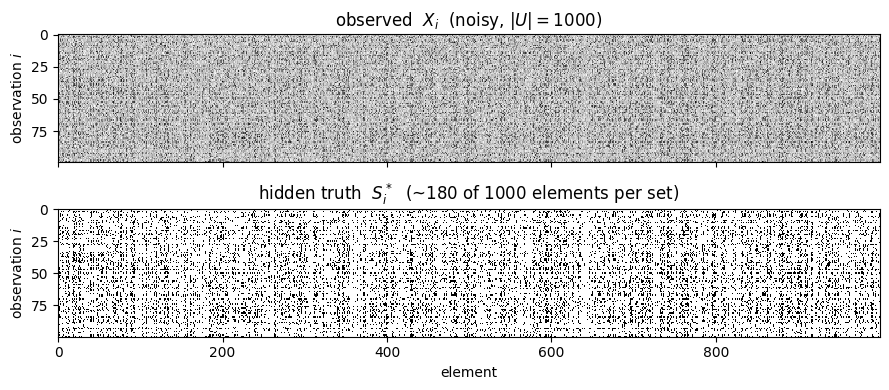

In [8]:
# peek at the new |U|=1000 instance: noisy observation (top) vs the hidden true set (bottom)
fig, ax = plt.subplots(2, 1, figsize=(9, 4), sharex=True, sharey=True)
ax[0].imshow(setoff_obs, aspect='auto', cmap='Greys', vmin=-1, vmax=2, interpolation='nearest')
ax[0].set_ylabel('observation $i$')
ax[0].set_title('observed  $X_i$  (noisy, $|U|=1000$)')
ax[1].imshow(setoff_truth, aspect='auto', cmap='Greys', vmin=0, vmax=1, interpolation='nearest')
ax[1].set_ylabel('observation $i$')
ax[1].set_xlabel('element')
ax[1].set_title('hidden truth  $S^*_i$  (~180 of 1000 elements per set)')
plt.tight_layout()
plt.show()

In [9]:
# ---- run the Demo 1 recipe unchanged (on-policy), plus the naive thresholding baseline ----
thr_big = (setoff_obs > 0.5).astype(int)                    # naive per-element baseline (as in Demo 1)
f1_thr  = per_set_f1(thr_big, setoff_truth)

np.random.seed(1)
torch.manual_seed(1)
rule_on  = make_rule()
ON_MODEL = './_tutorial_seton_model.pt'
t = time.time()
train_model_off_policy(rule_on, rule_on.learning_rate, rule_on.batchSize, offPolicy=False,
                       num_epochs=300, model_filename=ON_MODEL)
with quiet():
    pred_on = predict_sets(torch.load(ON_MODEL), rule_on)
    f1_on   = per_set_f1(pred_on, setoff_truth)
print(f"on-policy    (live, 300 ep)  median F1 = {np.median(f1_on):.3f}      ({time.time()-t:.0f}s)")
print(f"thresholding (baseline)      median F1 = {np.median(f1_thr):.3f}")
print(f"\n->  the recipe that won at |U|=100 now scores WORSE than naive thresholding.  Why?")

Epoch 1/300, Average Reward: -1474.91015625, Median: -1478.630859375
Epoch 11/300, Average Reward: -1465.14208984375, Median: -1477.871337890625
Epoch 21/300, Average Reward: -1454.1490478515625, Median: -1456.738037109375
Epoch 31/300, Average Reward: -1450.296875, Median: -1455.6796875
Epoch 41/300, Average Reward: -1448.375, Median: -1452.76513671875
Epoch 51/300, Average Reward: -1446.6865234375, Median: -1454.64013671875
Epoch 61/300, Average Reward: -1440.8856201171875, Median: -1448.971923828125
Epoch 71/300, Average Reward: -1433.0682373046875, Median: -1455.1707763671875
Epoch 81/300, Average Reward: -1426.5863037109375, Median: -1450.06201171875
Epoch 91/300, Average Reward: -1422.2589111328125, Median: -1433.4443359375
Epoch 101/300, Average Reward: -1417.9881591796875, Median: -1439.991943359375
Epoch 111/300, Average Reward: -1416.1700439453125, Median: -1439.4532470703125
Epoch 121/300, Average Reward: -1412.098876953125, Median: -1445.5576171875
Epoch 131/300, Average Re

### Why the same recipe collapses

Nothing about the model changed - only the **scale**. GReinSS learns by **sampling** candidate states
$S\sim\Pr(S\mid\theta)$ and rewarding the ones that explain each observation. At $|\mathcal U|=100$ the
sets are small enough that the untrained policy stumbles onto (nearly) the right set often enough to get
a learning signal.

At $|\mathcal U|=1000$ each true set is one specific **~180-of-1000** subset. Drawing that set - or
anything close enough to earn reward - *by chance* from an untrained $\Pr(S\mid\theta)$ essentially
**never happens**. So nearly every sampled trajectory gets ~zero reward, the gradient sees **no signal**
toward the right sets, and training stalls. It is a **needle-in-a-haystack sampling problem**, not a
modelling one - which is why more epochs would not rescue it.

### The fix: off-policy sampling

If sampling blindly from $\Pr(S\mid\theta)$ never finds the needle, **don't sample blindly.** Propose
states from a distribution that already knows roughly where to look - biased by the observation itself -
then **correct** for that bias with importance sampling, so the policy gradient stays an **unbiased**
maximum-likelihood estimator.

For this Gaussian model the proposal is simple: nudge each "add element $j$" action by the
log-likelihood ratio $(X_{i,j}-\tfrac12)/\sigma^2$ - elements the observation says are "on" get proposed
far more often, so trajectories actually reach the ~180-element sets. That single change is what
`offPolicy=True` turns on. Training with it is heavy (minutes), so we load the paper's **pre-trained
off-policy model** and score it.

In [10]:
# THE off-policy proposal used to pre-train the model: bias 'add element j' by (X_ij - 1/2)/sigma^2
_obsB = torch.as_tensor(setoff_obs).float()
def offPolicyRule_big(g, arange1):
    idx = np.asarray(arange1) % Nb
    bias = torch.zeros((g.shape[0], Ub+1))
    bias[:, :Ub] = (_obsB[idx] - 0.5)/(sig_b**2)
    return bias, torch.zeros((g.shape[0], 1))

# ---- load the pre-trained off-policy model (see tutorial/pretrain_setoff.py) and score it ----
rule_off  = make_rule()
rule_off.offPolicyRule = offPolicyRule_big
off_model = torch.load(os.path.join(ASSETS, 'setoff_model.pt'))   # trained with offPolicy=True
with quiet():
    pred_off = predict_sets(off_model, rule_off)
    f1_off   = per_set_f1(pred_off, setoff_truth)
print(f"off-policy   (pre-trained)   median F1 = {np.median(f1_off):.3f}      (paper: 0.938)")
print(f"\n->  the observation-biased proposal reaches sets on-policy never could - and beats thresholding.")

off-policy   (pre-trained)   median F1 = 0.940      (paper: 0.938)

->  the observation-biased proposal reaches sets on-policy never could - and beats thresholding.


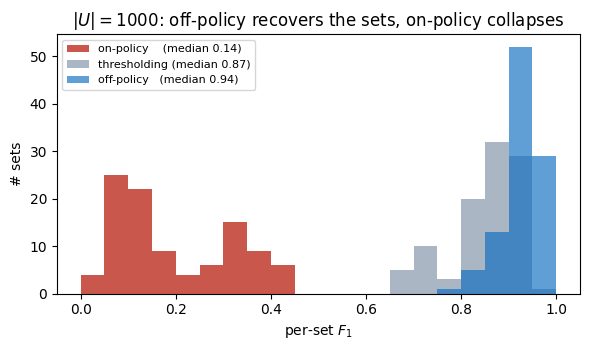

In [11]:
# visualize the gap: live per-set F1 distributions at |U|=1000 — thresholding, off-policy, on-policy
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(f1_on,  bins=20, range=(0,1), color='#c0392b', alpha=.85, label=f'on-policy    (median {np.median(f1_on):.2f})')
ax.hist(f1_thr, bins=20, range=(0,1), color='#7f8fa6', alpha=.65, label=f'thresholding (median {np.median(f1_thr):.2f})')
ax.hist(f1_off, bins=20, range=(0,1), color='#0b6cbf', alpha=.65, label=f'off-policy   (median {np.median(f1_off):.2f})')
ax.set_xlabel('per-set $F_1$')
ax.set_ylabel('# sets')
ax.legend(fontsize=8)
ax.set_title('$|U|=1000$: off-policy recovers the sets, on-policy collapses')
plt.tight_layout()
plt.show()

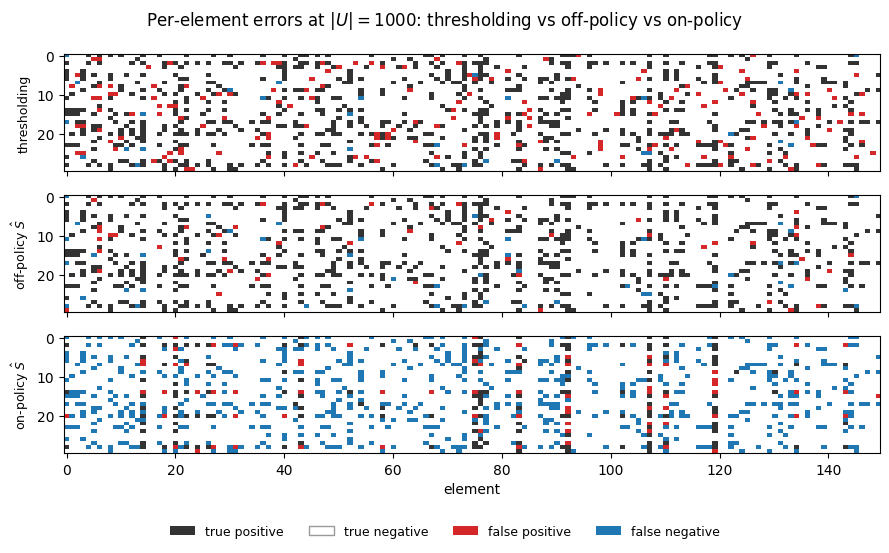

In [12]:
# per-element error patterns at |U|=1000: thresholding vs off-policy vs on-policy (reuses error_map/cmap/norm from Demo 1)
# |U|=1000 is too wide to show whole, so we crop to the first 30 observations x 150 elements.
obs_slice, el_slice = slice(0, 30), slice(0, 150)
fig, ax = plt.subplots(3, 1, figsize=(9, 5.4), sharex=True)
for a, M, t_ in zip(ax, [thr_big, pred_off, pred_on], ['thresholding', 'off-policy $\\hat S$', 'on-policy $\\hat S$']):
    a.imshow(error_map(M, setoff_truth)[obs_slice, el_slice], aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
    a.set_ylabel(t_, fontsize=9)
ax[-1].set_xlabel('element')
handles = [Patch(facecolor='#333333', label='true positive'),
           Patch(facecolor='#ffffff', edgecolor='#999999', label='true negative'),
           Patch(facecolor='#d62728', label='false positive'),
           Patch(facecolor='#1f77b4', label='false negative')]
fig.legend(handles=handles, ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           frameon=False, fontsize=9)
plt.suptitle('Per-element errors at $|U|=1000$: thresholding vs off-policy vs on-policy')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

---
# Demo 3 — Latent graph inference *(a third latent structure)*

**Same recipe, a completely different latent object.** Each state $S^*_i$ is now a **directed graph**
on 10 nodes (90 possible edges), and we observe only the **start and end points of $k$ absorbing random
walks** — a very indirect view. The forward model $\Pr(X\mid S)$ comes from the shifted-Laplacian
$(L+I)^{-1}$ random-walk process (provided as `sim1_fast_multi`).

Only the two ingredients change — a graph generator plus this $\Pr(X\mid S)$ — the machinery is
identical to Demos 1–2. Training is heavier, so we **load a pre-trained policy**
(see `tutorial/pretrain_graph.py`) and score edge-recovery $F_1$.

graph observations: (300, 10, 10) | ground-truth graphs: (300, 90)


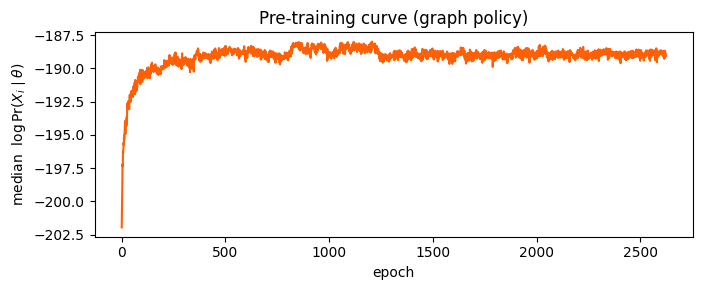

In [13]:
from sharedGen import sim1_log_calculate_pr_x_given_g, sim1_fast_multi

# ASSETS was defined in the setup cell (tutorial/assets)
graph_obs   = np.load(os.path.join(ASSETS, 'graph_obs.npz'))['arr_0']    # (D,10,10) start-end counts
graph_truth = np.load(os.path.join(ASSETS, 'graph_truth.npz'))['arr_0']  # (D,90)   true adjacency (off-diagonal)
GRAPH_MODEL = os.path.join(ASSETS, 'graph_model.pt')
print('graph observations:', graph_obs.shape, '| ground-truth graphs:', graph_truth.shape)

# pre-computed training curve
gloss = np.load(os.path.join(ASSETS, 'graph_loss.npz'))['arr_0']
plt.figure(figsize=(7,3))
plt.plot(gloss, color='#FF5F05')
plt.xlabel('epoch')
plt.ylabel('median  $\\log\\Pr(X_i\\mid\\theta)$')
plt.title('Pre-training curve (graph policy)')
plt.tight_layout()
plt.show()


inference in 10.4 s   ->  predictions (300, 90)
edge-recovery F1  -  median 0.966   mean 0.947


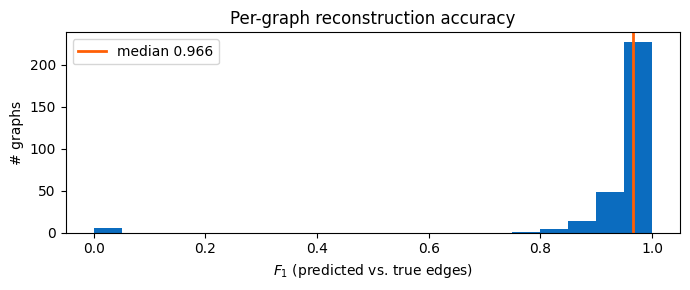

In [14]:
# rebuild the rule object for the graph problem and load the trained policy
STATE = 10 * 9   # 90 directed edges
grule = gClass()
grule.graphSize               = STATE
grule.observations_batch      = graph_obs
grule.batchSize               = 1000
grule.learning_rate           = 1e-3
grule.model                   = GraphGeneratorNet(STATE, 1, 50, endingBias=0)
grule.log_calculate_pr_x_given_g = sim1_log_calculate_pr_x_given_g
grule.multi_x_given_g            = sim1_fast_multi

t = time.time()
with quiet():
    gpred = np.array(simpleInference(grule, GRAPH_MODEL)).astype(int)   # predicted adjacency (D,90)
print(f'inference in {time.time()-t:.1f} s   ->  predictions {gpred.shape}')

def graph_f1(P, T):
    tp = ((P==1)&(T==1)).sum()
    fp = ((P==1)&(T==0)).sum()
    fn = ((P==0)&(T==1)).sum()
    prec = tp/(tp+fp+1e-9)
    rec = tp/(tp+fn+1e-9)
    return 2*prec*rec/(prec+rec+1e-9)

per_graph_f1 = np.array([graph_f1(gpred[i], graph_truth[i]) for i in range(len(gpred))])
print(f"edge-recovery F1  -  median {np.median(per_graph_f1):.3f}   mean {per_graph_f1.mean():.3f}")

plt.figure(figsize=(7,3))
plt.hist(per_graph_f1, bins=20, color='#0b6cbf')
plt.axvline(np.median(per_graph_f1), color='#FF5F05', lw=2, label=f'median {np.median(per_graph_f1):.3f}')
plt.xlabel('$F_1$ (predicted vs. true edges)')
plt.ylabel('# graphs')
plt.legend()
plt.title('Per-graph reconstruction accuracy')
plt.tight_layout()
plt.show()


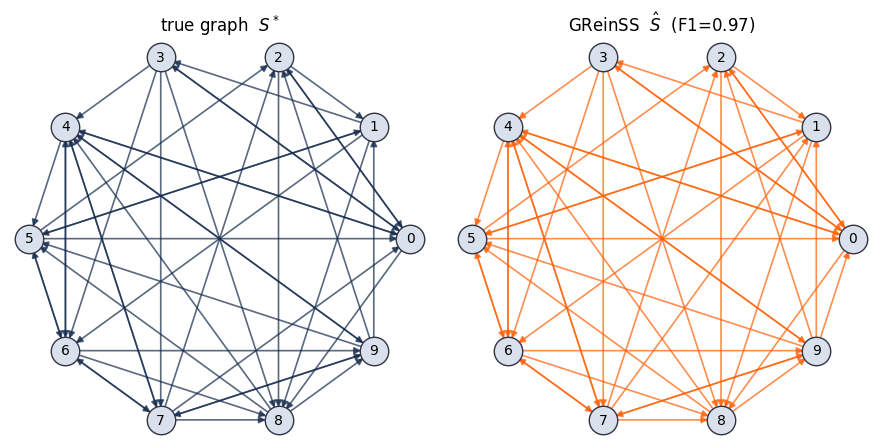

In [15]:
# visualize one reconstruction: true graph vs GReinSS prediction
def vec_to_adj(v, n=10):
    A = np.zeros((n, n), dtype=int)
    od = np.argwhere(np.eye(n) == 0)
    A[od[:,0], od[:,1]] = v
    return A

def draw(A, ax, title, color):
    n = A.shape[0]
    ang = np.linspace(0, 2*np.pi, n, endpoint=False)
    xy = np.c_[np.cos(ang), np.sin(ang)]
    for i in range(n):
        for j in range(n):
            if A[i,j]:
                ax.annotate('', xy=xy[j], xytext=xy[i],
                            arrowprops=dict(arrowstyle='-|>', color=color, alpha=.7,
                                            shrinkA=9, shrinkB=9, lw=1.2))
    ax.scatter(xy[:,0], xy[:,1], s=420, color='#d9e2ec', zorder=3, edgecolor='#334')
    for i,(x,y) in enumerate(xy): ax.text(x, y, str(i), ha='center', va='center', zorder=4)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')

idx = int(np.argsort(-per_graph_f1)[len(per_graph_f1)//2])   # a median-accuracy example
fig, ax = plt.subplots(1, 2, figsize=(9, 4.4))
draw(vec_to_adj(graph_truth[idx]), ax[0], f'true graph  $S^*$', '#13294B')
draw(vec_to_adj(gpred[idx]),       ax[1], f'GReinSS  $\\hat S$  (F1={per_graph_f1[idx]:.2f})', '#FF5F05')
plt.tight_layout()
plt.show()


---
# Intuition — why the denominator matters

A tiny problem shows the whole point. Three states $S_1,S_2,S_3$, two observations $X_1,X_2$:

$$\Pr(X_1\mid S_1)=0.5,\quad \Pr(X_2\mid S_2)=0.3,\quad \Pr(X_2\mid S_3)=0.2,\quad\text{(all others }0).$$

Each state is made by its own trajectory $\tau_j$. We optimize a 3-way softmax policy
$\Pr(\tau_j\mid\theta)$ by policy gradient — once with the **naive** reward
$r'(\tau)=\sum_i\Pr(X_i\mid\tau)$, once with the **GReinSS** reward
$r(\tau)=\sum_i \Pr(X_i\mid\tau)/\Pr(X_i\mid\theta)$.

In [16]:
# Pr(X_i | S_j):  rows = observations X1,X2 ; cols = states S1,S2,S3
PxS = np.array([[0.5, 0.0, 0.0],
                [0.0, 0.3, 0.2]])

def run(dynamic, steps=4000, lr=0.2):
    logits = torch.zeros(3, requires_grad=True)          # policy over the 3 trajectories
    opt = torch.optim.SGD([logits], lr=lr)
    for _ in range(steps):
        p = torch.softmax(logits, 0)                     # Pr(tau_j | theta)
        Px_theta = torch.tensor(PxS, dtype=torch.float) @ p          # Pr(X_i | theta)
        if dynamic:                                       # GReinSS: divide by Pr(X_i|theta)
            r = (torch.tensor(PxS, dtype=torch.float) / Px_theta[:, None]).sum(0)
        else:                                             # naive: raw reward
            r = torch.tensor(PxS.sum(0), dtype=torch.float)
        # policy-gradient surrogate: maximize sum_j detach(r_j) * Pr(tau_j)
        loss = -(r.detach() * p).sum()
        opt.zero_grad()
        loss.backward()
        opt.step()
    p = torch.softmax(logits, 0).detach().numpy()
    joint = (PxS @ p).prod()                              # Pr(X1|theta) * Pr(X2|theta)
    return p, joint

for name, dyn in [('naive policy gradient', False), ('GReinSS (dynamic reward)', True)]:
    p, joint = run(dyn)
    print(f"{name:26s} Pr(tau) = [{p[0]:.3f} {p[1]:.3f} {p[2]:.3f}]   joint Pr(X1,X2|theta) = {joint:.4f}")


naive policy gradient      Pr(tau) = [0.996 0.002 0.001]   joint Pr(X1,X2|theta) = 0.0005
GReinSS (dynamic reward)   Pr(tau) = [0.500 0.499 0.001]   joint Pr(X1,X2|theta) = 0.0375


**Result.**
- **Naive PG** chases the single highest reward ($\tau_1$), sets $\Pr(\tau_1)\to1$, and drives
  $\Pr(X_2\mid\theta)\to0$ — the joint likelihood collapses to **0**.
- **GReinSS** balances $\Pr(\tau_1)=\Pr(\tau_2)=0.5$, $\Pr(\tau_3)=0$, reaching the **optimal**
  joint likelihood $0.25\times0.15=\mathbf{0.0375}$.

The denominator $\Pr(X_i\mid\theta)$ makes a trajectory's reward *shrink as it succeeds*, so the
policy spreads over exactly the states the data needs instead of collapsing to the argmax.

> **Recap — the GReinSS recipe.** For *any* discrete latent structure you can grow incrementally
> — subsets, large subsets, directed graphs (Demos 1–3):
> 1. write a **generator** for $S$ (here `GraphGeneratorNet` adds elements/edges),
> 2. write the likelihood **$\Pr(X\mid S)$**,
> 3. `train_model_off_policy(...)`  →  4. `simpleInference(...)`.
>
> For hard instances, add an **observation-biased off-policy proposal** (Demo 2) — the ingredient that
> lets GReinSS scale to large universes. The same machinery underlies the cancer methods **CloMu**
> (mutation trees) and **CNRein** (single-cell CNVs), and the RNA-isoform results that beat RSEM.